A notebook building a pipeline for predicting `SalePrice` can be found here:
https://www.kaggle.com/db102291/housing-prices-rf-pipeline-w-gridsearch

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV
from IPython.display import display_html 

In [2]:
#This notebook extends the code from the Intermediate Machine Learning course
# Read the data
df = pd.read_csv('../input/house-prices-advanced-regression-techniques/train.csv', index_col='Id')
df.dropna(axis=0, subset=['SalePrice'], inplace=True)

cat_cols = [cname for cname in df.columns if df[cname].dtype == "object"]
num_cols = [cname for cname in df.columns if df[cname].dtype in ['int64', 'float64']]

# Summary Statistics

In [3]:
df_cat = (df[cat_cols].describe()).T.sort_index()
df_num = (df[num_cols].describe()).T.sort_index()

df1_style = df_cat.style.set_table_attributes("style='display:inline'").set_caption('Categorical Variables')
df2_style = df_num.style.set_table_attributes("style='display:inline'").set_caption('Numerical Variables')

display_html(df1_style._repr_html_() + "\xa0\xa0\xa0" + df2_style._repr_html_(), raw=True)

,count,unique,top,freq
Alley,91,2,Grvl,50
BldgType,1460,5,1Fam,1220
BsmtCond,1423,4,TA,1311
BsmtExposure,1422,4,No,953
BsmtFinType1,1423,6,Unf,430
BsmtFinType2,1422,6,Unf,1256
BsmtQual,1423,4,TA,649
CentralAir,1460,2,Y,1365
Condition1,1460,9,Norm,1260
Condition2,1460,8,Norm,1445


# Null Values

In [4]:
na_df = pd.DataFrame(df.isnull().sum().sort_values(ascending=False),
                    columns=["Count"])
na_df = na_df[na_df.Count > 0]
na_df["Type"] = ["Categorical" if x in cat_cols else "Numerical" for x in na_df.index]
na_df

,Count,Type
PoolQC,1453,Categorical
MiscFeature,1406,Categorical
Alley,1369,Categorical
Fence,1179,Categorical
FireplaceQu,690,Categorical
LotFrontage,259,Numerical
GarageType,81,Categorical
GarageCond,81,Categorical
GarageFinish,81,Categorical
GarageQual,81,Categorical


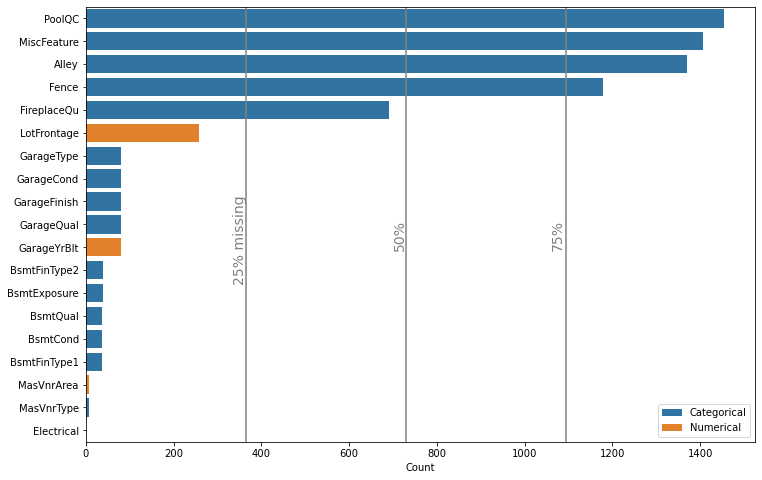

In [5]:
figure(figsize=(12, 8))
p = sns.barplot(x="Count", y=na_df.index, data=na_df, hue = "Type", dodge=False);
p.legend(loc='lower right')

p.axvline(1460*0.75, 0, color='grey')
p.text(1060, 10,'75%', rotation = 90, fontsize=14, color='grey');

p.axvline(1460*0.5, 0, color='grey')
p.text(700, 10,'50%', rotation = 90, fontsize=14, color='grey');

p.axvline(1460*0.25, 0, color='grey')
p.text(335, 11.5,'25% missing', rotation = 90, fontsize=14, color='grey');

# Numerical Variables

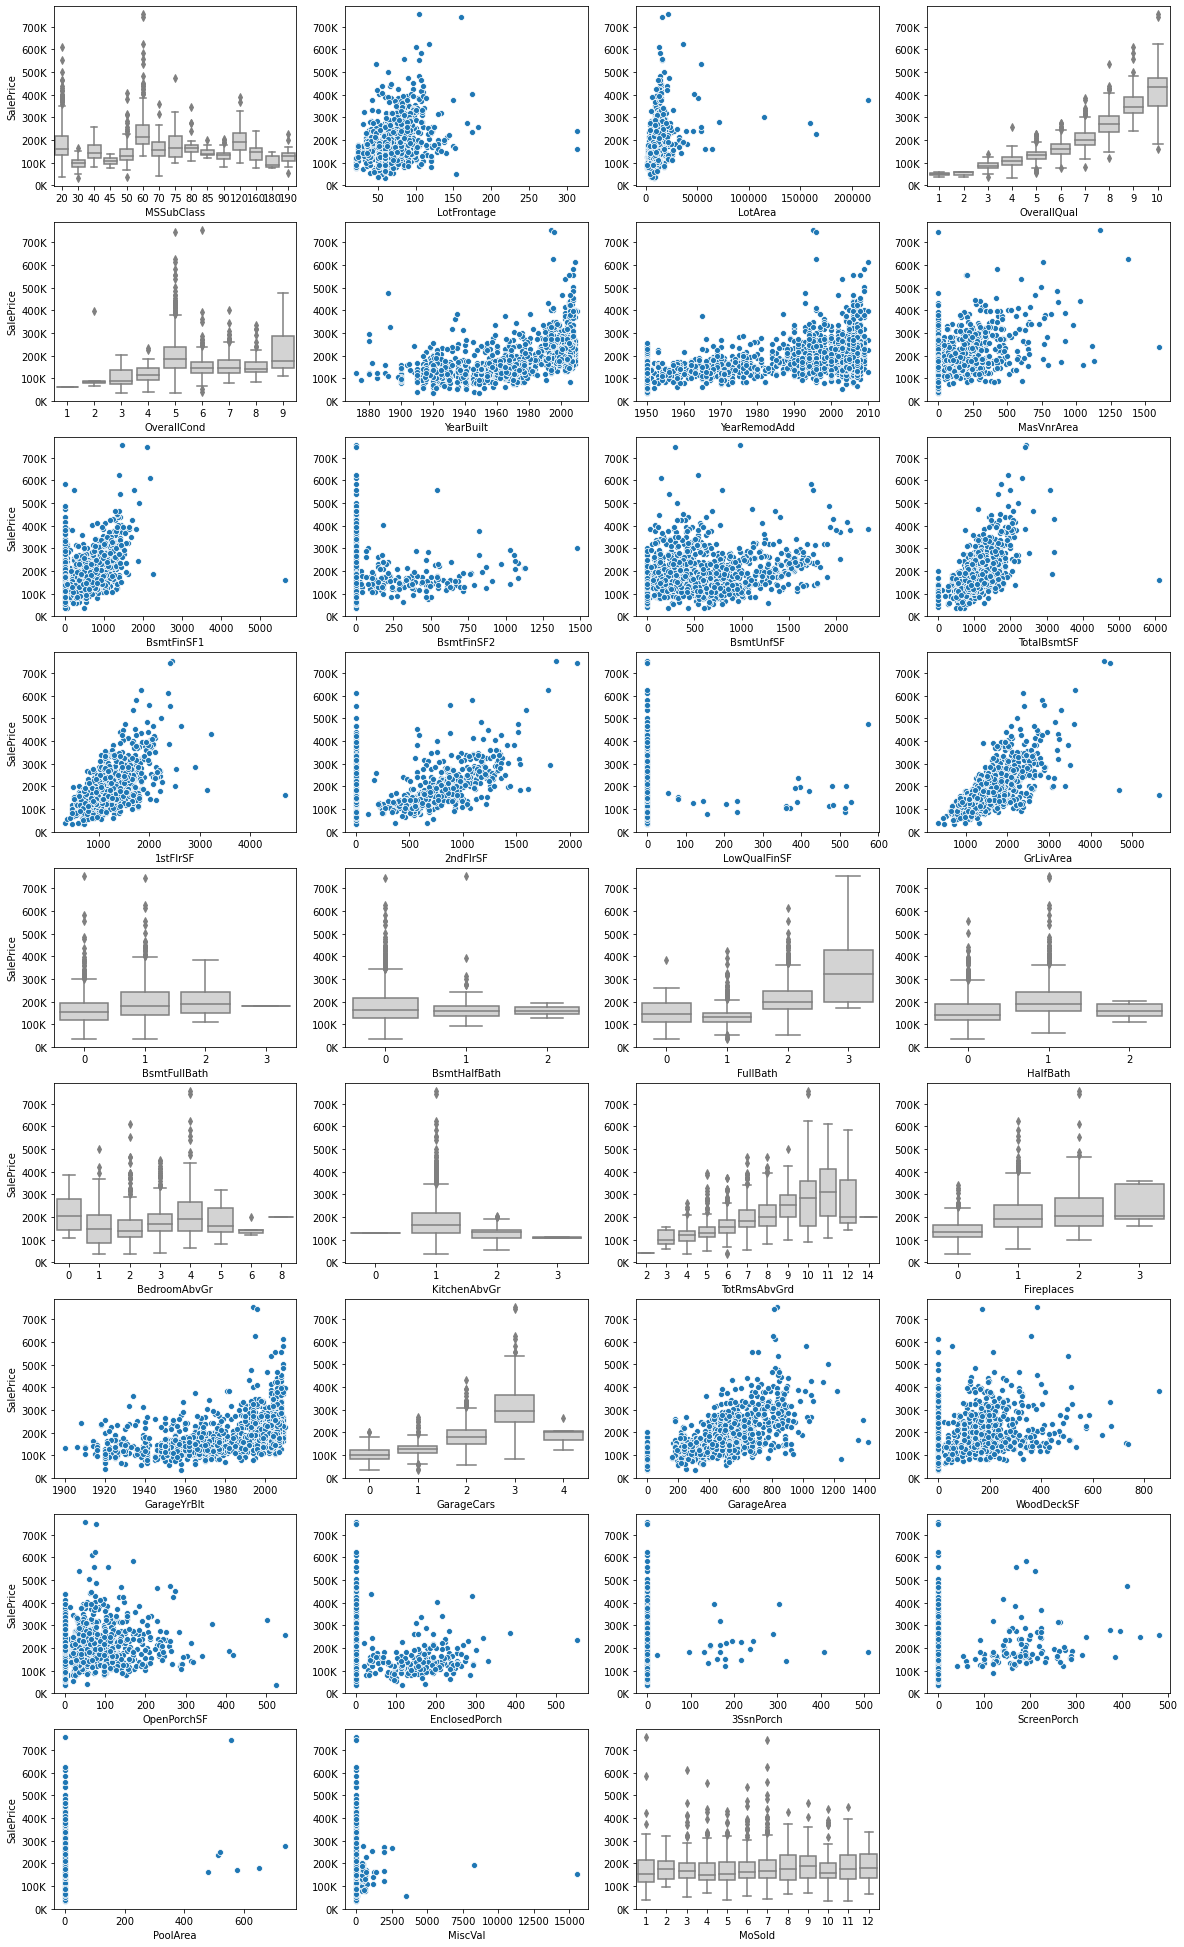

In [6]:
boxplot_cols = ["MSSubClass", "OverallQual", "OverallCond", "BsmtFullBath", "BsmtHalfBath", 
                "FullBath", "HalfBath", "BedroomAbvGr", "KitchenAbvGr", "TotRmsAbvGrd", 
                "Fireplaces", "GarageCars", "MoSold"]

figure(figsize=(20, 35))

for i in range(0,35):
    plt.subplot(9, 4, i+1)
    if num_cols[i] in boxplot_cols:
        p = sns.boxplot(x=num_cols[i], 
                        y=num_cols[36], 
                        data=df, 
                        color="lightgrey")
    else:
        p = sns.scatterplot(x=num_cols[i], 
                            y=num_cols[36], 
                            data=df)
    if i%4 != 0:
        p.set(ylabel='')
    ylabs = ['{:,.0f}'.format(x) + 'K' for x in p.get_yticks()/1000]
    p.set_yticklabels(ylabs)
        

# Categorical Variables

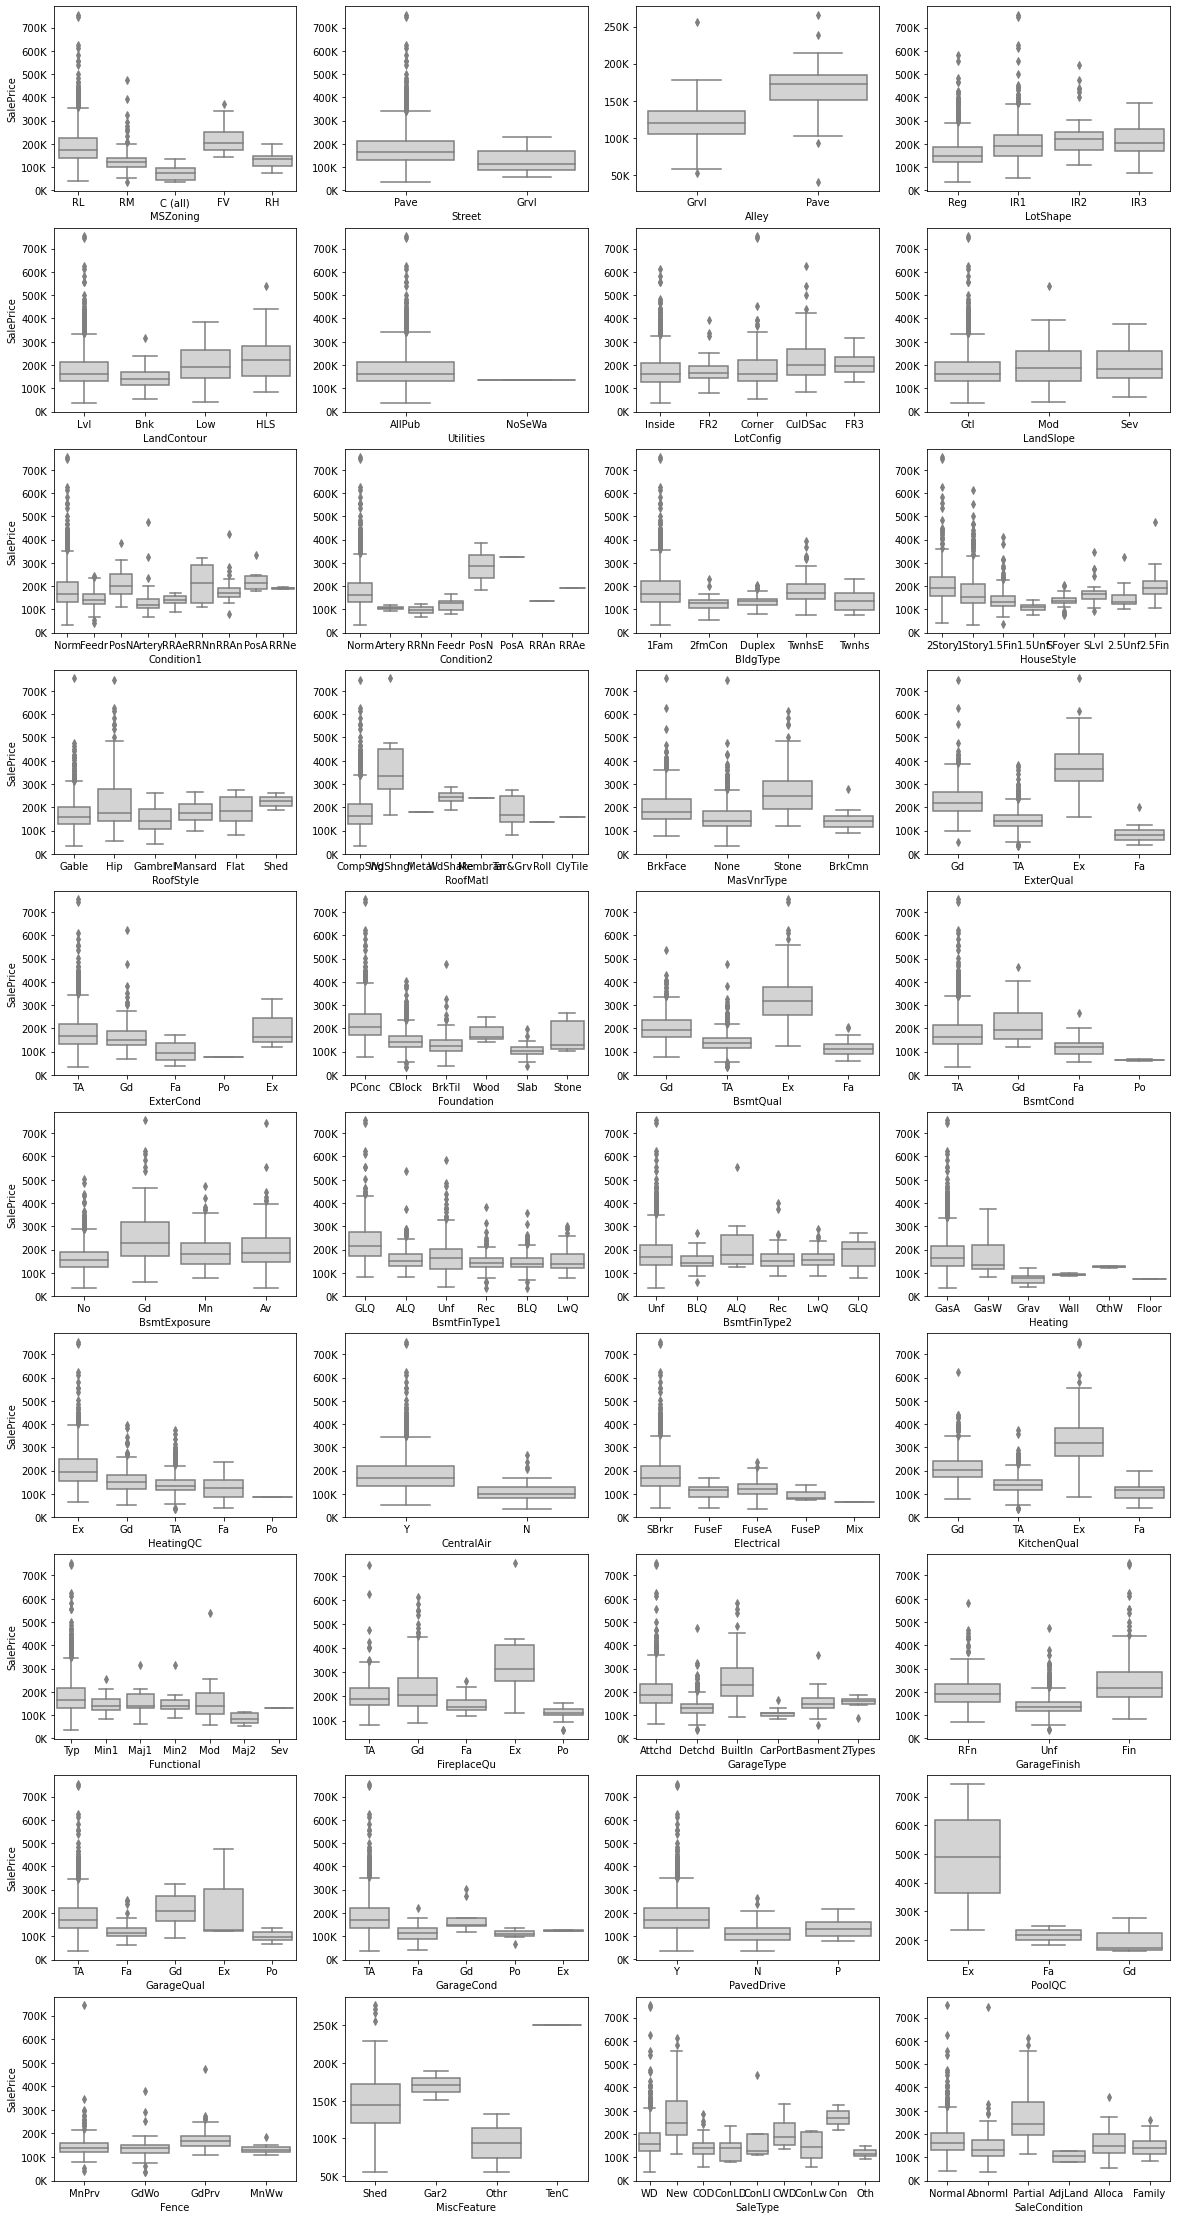

In [7]:
figure(figsize=(20, 40))

j = 0
for i in range(0,43):
    if len(df[cat_cols[i]].unique()) < 15:
        j += 1
        plt.subplot(10, 4, j)
        p = sns.boxplot(x=cat_cols[i], 
                        y=num_cols[36], 
                        data=df, 
                        color="lightgrey")
        if (j-1)%4 != 0:
            p.set(ylabel='')
        ylabs = ['{:,.0f}'.format(x) + 'K' for x in p.get_yticks()/1000]
        p.set_yticklabels(ylabs)